### __Text Representation and Embedding Techniques__

#### __Text Representation Techniques__

- __One Hot Encoding__
- __Bag of Words (BOW)__
- __Term Frequency-Inverse Document Frequency (TF-IDF)__
- __Latent Semantic Analysis (LSA)__
- __Latent Dirichlet Allocation (LDA)__


##### __One Hot Encoding__

In [1]:
# One Hot Encoding in Machine Learning Using Pandas

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)
print(f"Original Employee Data:\n{df}\n")

df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)
print(f"One-Hot Encoded Data using Pandas:\n{df_pandas_encoded}\n")

categorical_columns = ['Gender', 'Remarks']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=encoder.get_feature_names_out(categorical_columns))

df_sklearn_encoded = pd.concat([df.drop(categorical_columns, axis=1), one_hot_df], axis=1)

print(f"One-Hot Encoded Data using Scikit-Learn:\n{df_sklearn_encoded}\n")

Original Employee Data:
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice

One-Hot Encoded Data using Pandas:
   Employee id  Gender_M  Remarks_Great  Remarks_Nice
0           10      True          False         False
1           20     False          False          True
2           15     False          False         False
3           25      True           True         False
4           30     False          False          True

One-Hot Encoded Data using Scikit-Learn:
   Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           20       1.0       0.0           0.0            0.0           1.0
2           15       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4   

In [2]:
# Using Scikit Learn Library

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {'Employee id': [10, 20, 15, 25, 30],
        'Gender': ['M', 'F', 'F', 'M', 'F'],
        'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice'],
        }
df = pd.DataFrame(data)
print(f"Employee data : \n{df}")

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

Employee data : 
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice
Encoded Employee data : 
   Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           20       1.0       0.0           0.0            0.0           1.0
2           15       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4           30       1.0       0.0           0.0            0.0           1.0


In [3]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # needed in newer nltk versions

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hassaan_PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hassaan_PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hassaan_PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

##### __Bag of words (BoW) model in NLP__

In [4]:
## Step 1: Preprocessing the Text


import nltk
import re
import pandas as pd
from nltk.corpus import stopwords

text = """Beans. I was trying to explain to somebody as we were flying in, that's corn.
         That's beans. And they were very impressed at my agricultural knowledge. 
         Please give it up for Amaury once again for that outstanding introduction. 
         I have a bunch of good friends here today, including somebody who I served with, 
         who is one of the finest senators in the country, and we're lucky to have him, 
         your Senator, Dick Durbin is here. I also noticed, by the way, 
         former Governor Edgar here, who I haven't seen in a long time, and 
         somehow he has not aged and I have. And it's great to see you, Governor. 
         I want to thank President Killeen and everybody at the U of I System for 
         making it possible for me to be here today. And I am deeply honored at the Paul 
         Douglas Award that is being given to me. He is somebody who set the path for so 
         much outstanding public service here in Illinois. Now, I want to start by 
         addressing the elephant in the room. I know people are still wondering why 
         I didn't speak at the commencement."""

dataset = nltk.sent_tokenize(text)

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

for i, sentence in enumerate(dataset):
    print(f"Sentence {i+1}: {sentence}")


Sentence 1: beans 
Sentence 2: i was trying to explain to somebody as we were flying in that s corn 
Sentence 3: that s beans 
Sentence 4: and they were very impressed at my agricultural knowledge 
Sentence 5: please give it up for amaury once again for that outstanding introduction 
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here 
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have 
Sentence 8: and it s great to see you governor 
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today 
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me 
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois 
Sente

In [5]:
## Step 2: Counting Word Frequencies

word2count = {}

for data in dataset:
    words = nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1

stop_words = set(stopwords.words('english'))

filtered_word2count = {word: count for word, count in word2count.items() if word not in stop_words}

word_freq_df = pd.DataFrame(list(filtered_word2count.items()), columns=['Word', 'Frequency'])

word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

print(word_freq_df)

            Word  Frequency
3       somebody          3
0          beans          2
17         today          2
12   outstanding          2
41          want          2
..           ...        ...
67        people          1
68         still          1
69     wondering          1
70         speak          1
71  commencement          1

[72 rows x 2 columns]


Top 10 frequent words: ['i', 'the', 'to', 'and', 'in', 'for', 'here', 'that', 'at', 'who']


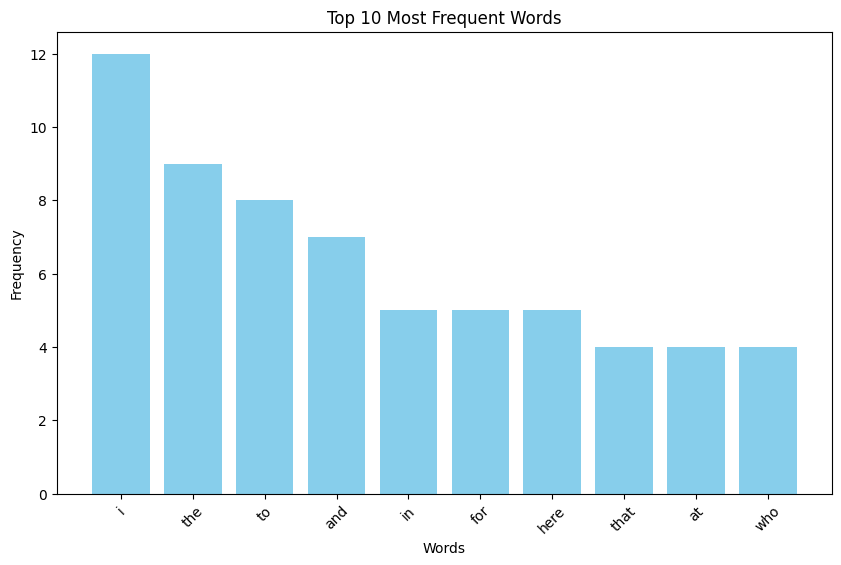

In [6]:
## Step 3: Selecting the Most Frequent Words

import heapq
import matplotlib.pyplot as plt

freq_words = heapq.nlargest(10, word2count, key=word2count.get)

print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

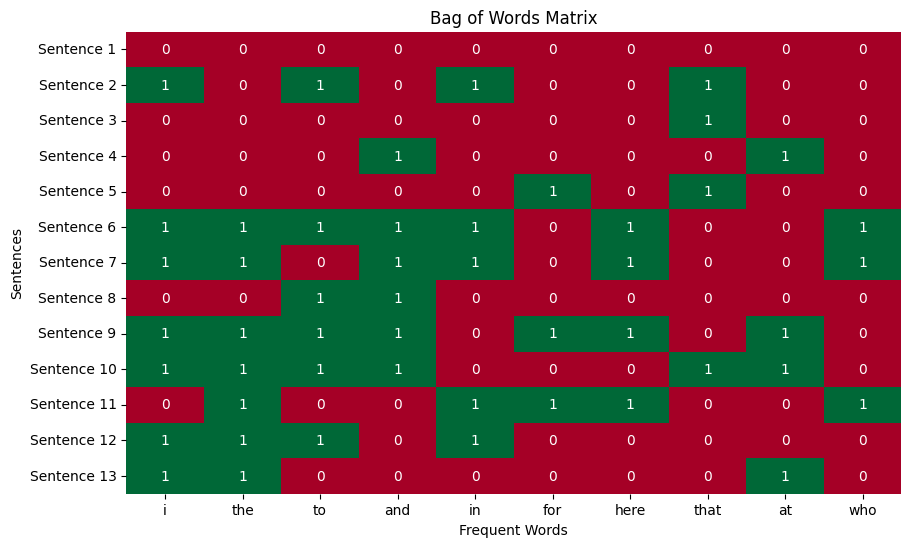

In [7]:
## Step 4: Building the Bag of Words (BoW) Model

import numpy as np
import seaborn as sns

X = []

for data in dataset:
    vector = []
    for word in freq_words:
        if word in nltk.word_tokenize(data):
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn', cbar=False, annot=True, fmt="d", xticklabels=freq_words, yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))])

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

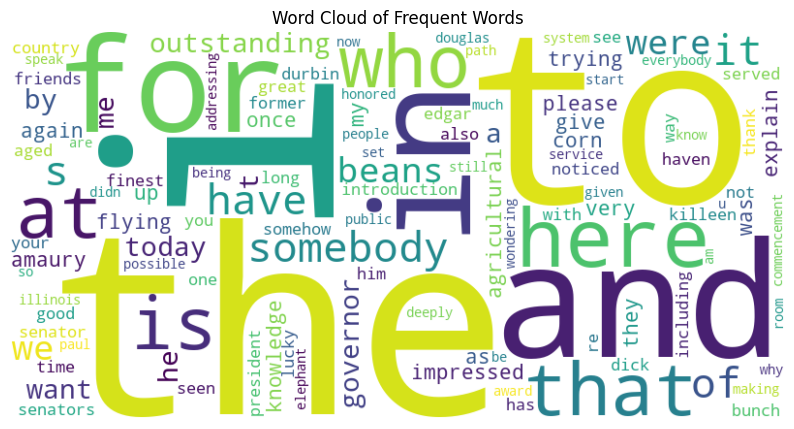

In [10]:
## Step 5: Visualizing Word Frequencies with a Word Cloud

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words")
plt.show()

##### __Term Frequency-Inverse Document Frequency (TF-IDF)__

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

d0 = 'Geeks for geeks'
d1 = 'Geeks'
d2 = 'r2j'
string = [d0, d1, d2]

tfidf = TfidfVectorizer()
result = tfidf.fit_transform(string)

print('\nidf values:')
for ele1, ele2 in zip(tfidf.get_feature_names_out(), tfidf.idf_):
    print(ele1, ':', ele2)

print('\nWord indexes:')
print(tfidf.vocabulary_)
print('\ntf-idf value:')
print(result)
print('\ntf-idf values in matrix form:')
print(result.toarray())


idf values:
for : 1.6931471805599454
geeks : 1.2876820724517808
r2j : 1.6931471805599454

Word indexes:
{'geeks': 1, 'for': 0, 'r2j': 2}

tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	0.8355915419449176
  (0, 0)	0.5493512310263033
  (1, 1)	1.0
  (2, 2)	1.0

tf-idf values in matrix form:
[[0.54935123 0.83559154 0.        ]
 [0.         1.         0.        ]
 [0.         0.         1.        ]]


##### __Latent Dirichlet Allocation (LDA)__

In [1]:
# Step 1: Install and Import Libraries
# (Run !pip install only once, then you can comment it out)
!pip install gensim pyLDAvis spacy pandas scikit-learn nltk

import pandas as pd
import string
import spacy
import nltk
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from nltk.corpus import stopwords
import en_core_web_md

# Download required NLTK/spaCy data
nltk.download('wordnet')
nltk.download('stopwords')
spacy.cli.download("en_core_web_md")

You should consider upgrading via the 'C:\nlp_env\Scripts\python.exe -m pip install --upgrade pip' command.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hassaan_PC\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hassaan_PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Step 2: Load Data
import pandas as pd

data = {
    'business_id': [
        'b1','b1','b1','b2','b2','b2','b3','b3','b3','b4',
        'b4','b4','b5','b5','b5','b6','b6','b6','b7','b7'
    ],
    'user_id': [
        'u1','u2','u3','u1','u4','u5','u2','u3','u6','u1',
        'u7','u8','u3','u5','u9','u2','u4','u7','u6','u8'
    ],
    'stars': [5,4,3,1,2,1,5,4,5,3,2,4,5,5,4,1,2,1,4,3],
    'text': [
        'The food was absolutely amazing, best pizza in town. Great service and friendly staff.',
        'Really good burgers and fries. The atmosphere was nice and cozy. Will come back again.',
        'Decent food but service was a bit slow. The pasta was okay but nothing special.',
        'Terrible experience. Waited over an hour for cold food. Staff was rude and unhelpful.',
        'Very disappointing. The chicken was dry and overcooked. Never coming back here.',
        'Worst restaurant ever. Bad food, bad service, overpriced and dirty environment.',
        'Absolutely love this place! The sushi is fresh and delicious. Staff is always welcoming.',
        'Great ambiance and wonderful food. The ramen was perfect. Highly recommend this spot.',
        'Best Japanese food in the city. Clean restaurant, fast service, and amazing quality.',
        'Average experience. Food was okay but nothing memorable. Prices are reasonable though.',
        'The steak was undercooked and the waiter was not attentive. Mediocre at best.',
        'Solid food and good portion sizes. Service could be faster but overall enjoyable.',
        'Incredible brunch spot! The eggs benedict and mimosas were outstanding. Love it here.',
        'Amazing coffee and pastries. Perfect place to work and relax. Very cozy atmosphere.',
        'Great breakfast options. Staff is friendly and the food comes out quickly. Very clean.',
        'Horrible coffee and stale pastries. Overpriced for the quality. Very disappointing visit.',
        'Waited 30 minutes for a simple sandwich. Staff ignored us completely. Will not return.',
        'Dirty tables and slow service. The soup was cold and tasteless. Very bad experience.',
        'Good tacos and burritos. Authentic Mexican flavors and generous portions. Great value.',
        'Nice little Mexican place. Food was fresh and tasty. Service was friendly and quick.'
    ]
}

yelp_review = pd.DataFrame(data)
print("Number of reviews:", len(yelp_review))
print("Unique businesses:", yelp_review['business_id'].nunique())
print("Unique users:", yelp_review['user_id'].nunique())
yelp_review.head()

Number of reviews: 20
Unique businesses: 7
Unique users: 9


,business_id,user_id,stars,text
0,b1,u1,5,"The food was absolutely amazing, best pizza in..."
1,b1,u2,4,Really good burgers and fries. The atmosphere ...
2,b1,u3,3,Decent food but service was a bit slow. The pa...
3,b2,u1,1,Terrible experience. Waited over an hour for c...
4,b2,u4,2,Very disappointing. The chicken was dry and ov...


In [7]:
# Step 3: Preprocess Text
# 3.1 Clean text
def clean_text(text):
    delete_dict = {sp_char: '' for sp_char in string.punctuation}
    delete_dict[' '] = ' '
    table = str.maketrans(delete_dict)
    text1 = text.translate(table)
    textArr = text1.split()
    text2 = ' '.join([w for w in textArr if not w.isdigit() and len(w) > 3])
    return text2.lower()

yelp_review['text'] = yelp_review['text'].apply(clean_text)
yelp_review['Num_words_text'] = yelp_review['text'].apply(
    lambda x: len(str(x).split()))

print(yelp_review[['text', 'Num_words_text']].head())

                                                text  Num_words_text
0  food absolutely amazing best pizza town great ...              10
1  really good burgers fries atmosphere nice cozy...              11
2  decent food service slow pasta okay nothing sp...               8
3  terrible experience waited over hour cold food...              10
4  very disappointing chicken overcooked never co...               8


In [9]:
# 3.2 Remove Stopwords
stop_words = stopwords.words('english')

def remove_stopwords(text):
    textArr = text.split(' ')
    rem_text = " ".join([i for i in textArr if i not in stop_words])
    return rem_text

yelp_review['text'] = yelp_review['text'].apply(remove_stopwords)

# verify
print(yelp_review['text'].head())

0    food absolutely amazing best pizza town great ...
1    really good burgers fries atmosphere nice cozy...
2    decent food service slow pasta okay nothing sp...
3    terrible experience waited hour cold food staf...
4    disappointing chicken overcooked never coming ...
Name: text, dtype: object


In [11]:
# 3.3 Lemmatization (nouns, adjectives only)
nlp = en_core_web_md.load(disable=['parser', 'ner'])

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ']):
    output = []
    for sent in texts:
        doc = nlp(sent)
        output.append(
            [token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return output

text_list = yelp_review['text'].tolist()
tokenized_reviews = lemmatization(text_list)

# verify
print(tokenized_reviews[:3])

[['food', 'amazing', 'good', 'pizza', 'town', 'great', 'service', 'friendly', 'staff'], ['good', 'burger', 'fry', 'nice', 'cozy'], ['decent', 'food', 'service', 'slow', 'pasta', 'special']]


In [13]:
# Step 4: Create Document-Term Matrix
dictionary = corpora.Dictionary(tokenized_reviews)

if len(dictionary) > 0:
    doc_term_matrix = [dictionary.doc2bow(rev) for rev in tokenized_reviews]
else:
    doc_term_matrix = []

# verify
print("Vocabulary size:", len(dictionary))
print("Sample doc-term vector:", doc_term_matrix[0])
print("Sample words:", [dictionary[i] for i, _ in doc_term_matrix[0]])

Vocabulary size: 79
Sample doc-term vector: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)]
Sample words: ['amazing', 'food', 'friendly', 'good', 'great', 'pizza', 'service', 'staff', 'town']


In [14]:
# Step 5: Fit LDA Model

if doc_term_matrix:
    LDA = gensim.models.ldamodel.LdaModel
    lda_model = LDA(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=10,
        random_state=100,
        chunksize=1000,
        passes=50,
        iterations=100
    )
    print(lda_model.print_topics())
else:
    print("Document term matrix is empty, cannot build LDA model.")

[(0, '0.079*"staff" + 0.079*"simple" + 0.079*"sandwich" + 0.079*"minute" + 0.079*"chicken" + 0.079*"disappointing" + 0.007*"good" + 0.007*"amazing" + 0.007*"town" + 0.007*"burger"'), (1, '0.013*"service" + 0.013*"amazing" + 0.013*"friendly" + 0.013*"food" + 0.013*"good" + 0.013*"great" + 0.013*"pizza" + 0.013*"staff" + 0.013*"town" + 0.013*"burger"'), (2, '0.084*"good" + 0.084*"food" + 0.044*"nice" + 0.044*"amazing" + 0.044*"great" + 0.044*"spot" + 0.044*"ambiance" + 0.044*"raman" + 0.044*"wonderful" + 0.044*"japanese"'), (3, '0.053*"service" + 0.053*"cold" + 0.053*"experience" + 0.053*"dirty" + 0.053*"slow" + 0.053*"tasteless" + 0.053*"table" + 0.053*"soup" + 0.053*"attentive" + 0.053*"mediocre"'), (4, '0.041*"portion" + 0.041*"mexican" + 0.041*"great" + 0.041*"restaurant" + 0.041*"outstanding" + 0.041*"egg" + 0.041*"incredible" + 0.041*"bad" + 0.041*"brunch" + 0.041*"love"'), (5, '0.065*"disappointing" + 0.065*"quality" + 0.065*"coffee" + 0.065*"pastry" + 0.065*"visit" + 0.065*"stale

In [15]:
# Step 6: Model Evaluation

total_docs = len(doc_term_matrix)
if total_docs > 0:
    print('\nPerplexity:', lda_model.log_perplexity(
        doc_term_matrix, total_docs=total_docs))
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=tokenized_reviews,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_lda = coherence_model_lda.get_coherence()
    print('Coherence:', coherence_lda)
else:
    print("No documents to evaluate coherence or perplexity.")


Perplexity: -5.446349390983581
Coherence: 0.4316263326332992


In [20]:
# Step 5: Visualization
import numpy as np
import warnings
warnings.filterwarnings('ignore')

if len(doc_term_matrix) > 0:
    vis_data = gensimvis.prepare(lda_model, doc_term_matrix, dictionary, mds='mmds')
    
    pyLDAvis.save_html(vis_data, 'lda_visualization.html')
    print("Saved! Open lda_visualization.html in your browser.")
    
    # Display inline in notebook
    from IPython.display import display
    display(vis_data)

else:
    print("No documents for visualization.")

Saved! Open lda_visualization.html in your browser.


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.055940  0.175426       1        1  34.709334
4     -0.042024 -0.172864       2        1  14.482036
2     -0.157063 -0.056454       3        1  12.915419
7     -0.125056  0.056618       4        1  11.156671
3      0.116840 -0.122755       5        1  10.375733
5      0.145673  0.050659       6        1   7.320158
0      0.083856  0.086406       7        1   4.980162
1      0.011238 -0.005679       8        1   1.353496
6      0.011238 -0.005679       9        1   1.353496
9      0.011238 -0.005679      10        1   1.353496, topic_info=             Term      Freq     Total Category  logprob  loglift
7           staff  3.000000  3.000000  Default  30.0000  30.0000
3            good  3.000000  3.000000  Default  29.0000  29.0000
24  disappointing  1.000000  1.000000  Default  28.0000  28.0000
29          place  2.000000  2.000000  Default  27.0000  27.0000
55         pastry  1.000000  1.000000  Default  26.0000  26.0000
..            ...       ...       ...      ...      ...      ...
21       terrible  0.021416  1.290357  Topic10  -4.3694   0.2039
22      unhelpful  0.021416  1.290357  Topic10  -4.3694   0.2039
24  disappointing  0.021416  1.489362  Topic10  -4.3694   0.0605
26          dirty  0.021416  1.793587  Topic10  -4.3694  -0.1254
29          place  0.021416  2.468581  Topic10  -4.3694  -0.4448

[477 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         1  0.388272     amazing
0         3  0.388272     amazing
0         4  0.388272     amazing
30        3  0.870749    ambiance
53        4  0.879608  atmosphere
...     ...       ...         ...
74        2  0.852492       value
63        6  0.960148       visit
43        5  0.892355      waiter
33        3  0.870749   wonderful
57        4  0.879608        work

[103 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 5, 3, 8, 4, 6, 1, 2, 7, 10])